## 2.4 파이토치 코드 맛보기
파이토치를 사용하여 간단한 분류 및 회귀 모벨을 개발하는 방법을 살펴보겠습니다.

car_evaluation.csv 파일을 데이터셋으로 사용합니다. 데이터셋을 열어 보면 다음과 같이 특성(칼럼) 일곱 개로
구성되어 있습니다.
1. price(지동차 가격)
2. maint(지동차 유지 비용)
3. doors(자동차 문 개수)
4. persons(수용 인원)
5. lug_capacity(수하물 용량)
6. safety(안전성)
7. output(차 상태): 이 데이터는 unacc(허용 불가능한 수준) 및 acc(허용 가능한 수준) , 양호
(good) 및 매우 좋은(very good, vgood) 중 하나의 값을 갖습니다.

이때 1~6의 칼럼 정보를 이용하여 일곱 번째 칼럼(차 상태)을 예측하는 코드를 구현해 보겠습니ㅏㄷ.

먼저 칠요한 라이브러리를 설치합니다. 터미널 커맨드라이(아나콘다 프롬프트)에서 pip 명령어를 사용하여 다음 라이브러리를 설치합니다.

In [2]:
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

이미 설치되어 있다면 다음 명령으로 업그레이드를 진행합니다.

In [3]:
!pip install --upgrade matplotlib --use-feature=2020-resolver
!pip install --upgrade seaborn --use-feature=2020-resolver
!pip install --upgrade scikit-learn --use-feature=2020-resolver


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [opti

이제 필요한 라이브러리(혹은 패키지)를 호출합니다.

In [4]:
import torch
import torch .nn as nn
import numpy as np # 벡터 및 행렬 연산에서 매우 편리한 기능을 제공하는 파이썬 라이브러리 패키지
import pandas as pd # 데이터 처리를 위해 널리 사용되는 파이씬 라01브러리 패키지
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

내려받은 데이터를 불러옵니다. 데이터는 예제 파일의 car_evaluation.csv입니다.

In [5]:
dataset = pd.read_csv('car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


1. pd.read_csv() 메서드를 이용하여 car_evaluation.csv 파일을 불러옵니다.
2. 데이터프레임 내의 처음 n줄을 출력해서 데이터의 내용을 확인할 수 있습니다. n의 기본값은 5입니다. 이와 유사한 방법으로 데이터의 내용을 확인할 수 있는 것으로 dataset.tail()이 있습니다. 이것은 데이터프레임 내의 마지막 n줄의 데이터를 출력합니다.

출력 결과 다섯 개의 행이 단어와 숫자로 구성되어 있는 것을 확인할 수 있습니다. 컴퓨터는 인간의 언어인 단어를 인식할 수 없기 때문에 단어를 벡터로 바꾸어 주는 임베딩(embedding) 처리가 필요합니다.

주어진 데이터셋을 이애하기 쉽도록 분포 형태로 시각화하여 표현하면 다음과 같습니다.

<Axes: ylabel='count'>

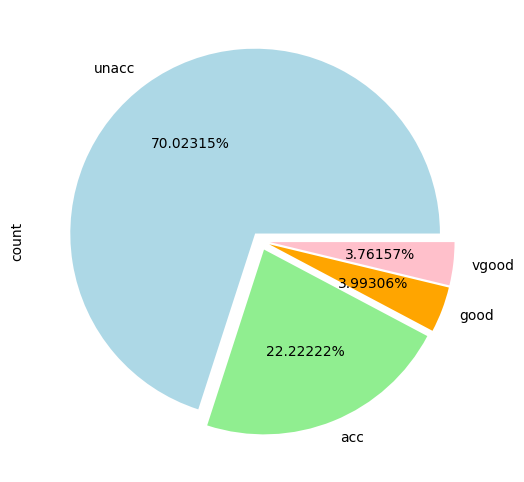

In [8]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
                                   colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))

결과에 따르면 대부분의 자동차(70%)는 허용 불가능한 상태에 있고 20%만 허용 가능한 수준입니다. 즉, 양호한 상태의 자동차 비율이 매우 낮은 것을 볼 수 있습니다. 예제 데이터 정보를 확인했으니 본격적으로 데이터에 대한 전처리를 해 봅시다.

딥러닝은 통계 알고리즘을 기반으로 하기 때문에 단어를 숫자(텐서)로 변환해야 합니다. 가장 먼저 필요한 전처리를 데이터를 파악하는 것입니다. 주어진 데이터의 형태를 파악한 후 숫자로 변환해 주어야 하는데, 예제에서 다루는 데이터의 칼럼들은 모두 범주형 데이터로 구성되어 있습니다. 다음 코드로 단어를 배열로 변환하는 방법에 대해 간단히 살펴보겠습니다.

이제 분석하기 좋게 데이터를 고치는 데이터 전처리를 해야 합니다. 먼저 astype() 메서드를 이용하여 범주 특성을 갖는 데이터를 범주형 타입으로 변환합니다. 또한, 파이토치를 이용한 모델 학습을 해야 하므로 범주형 타입을 텐서로 변환해야 합니다.

In [10]:
categorical_columns = ['price','maint','doors','persons','lug_capacity','safety'] # 예제 데이터셋 칼럼들의 목록
for category in categorical_columns:
  dataset[category] = dataset[category].astype('category') # astype() 메서드를 이용하여 데이터를 범주형으로 변환

price = dataset['price'] .cat.codes.values # 1
maint = dataset['maint'] .cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values
categorical_data = np.stack([price, maint, doors , persons, lug_capacity, safety] , 1) # 2
categorical_data [ : 10 ] # 합친 넘파이 배열 중 열 개의 행을 출력하여 보여 줍니다.

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

1. 범주형 데이터를 텐서로 변환하기 위해 다음과 같은 절차가 필요합니다.

**범주형 데이터 -> dataset[category] -> 넘파이 배열(NumPy array) -> 텐서(Tensor)**

즉, 파이토치로 모델을 학습시키기 위해서는 텐서 형태로 변환해야 하는데, 넘파이 배열을 통해 텐서를 생성할 수 있습니다.

범주형 데이터(단어)를 숫자(넘파이 배열)로 변환하기 위해 cat.codes를 사용합니다. cat.codes는 어떤 클래스가 어떤 숫자로 매핑되어 있는지 확인이 어려운 단점이 있으므로 주의해서 사용해야 합니다.

2. np.stack은 두 개 이상의 넘파이 객체를 합칠 때 사용합니다.

이제 torch 모듈을 이용하여 배열을 텐서로 변환합니다.

In [11]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

마지막으로 레이블(outputs)로 사용할 칼럼에 대해서도 텐서로 변환해 줍니다. 이번에는 get_dummies를 이용하여 넘파이 배열로 변환합니다.

In [13]:
outputs = pd.get_dummies(dataset.output) # 1
outputs = outputs.values
outputs = torch.tensor(outputs).flatten() # 1차원 텐서로 변환

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


1. get_dummies는 가변수(dummy variable)로 만들어 주는 함수입니다. 가변수로 만들어 준다는 의미는 문자를 숫자(0,1)로 바꾸어 준다는 의미입니다. 예를 위해 성별, 몸무게, 국적이라는 칼럼을 갖는 배열을 생성해 보겠습니다.

In [14]:
import pandas as pd
import numpy as np

data = {
    'gender' : ['male','female','male'],
    'weight' : [72, 55,68 ],
    'nation' : ['Japan','Korea','Australia']
}
df = pd.DataFrame(data)
df

,gender,weight,nation
0,male,72,Japan
1,female,55,Korea
2,male,68,Australia


성별과 국적을 숫자로 변환하기 위해 get_dummies()를 적용합니다.

In [15]:
pd.get_dummies(df)

,weight,gender_female,gender_male,nation_Australia,nation_Japan,nation_Korea
0,72,False,True,False,True,False
1,55,True,False,False,False,True
2,68,False,True,True,False,False


원래 숫자의 값을 가졌던 몸무게는 변화가 없고 성별과 국적만 0과 1로 변경된 것을 확인할 수 있습니다.

코드를 실행하면 앞에서 텐서로 변환한 범주형 데이터와 레이블에 대한 형태가 출력됩니다.

워드 임베딩은 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법입니다. 또한, 높은 차원의 임베딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있습니다. 따라서 단일 숫자로 변환된 념파이 배열을 N차원으로 변경하여 사용합니다.

배열을 N차원으로 변환하기 위해 먼저 모든 범주형 칼럼에 대한 임베딩 크기(벡터 차원)를 정의합니다. 임베딩 크기에 대한 정확한 규칙은 없지만 칼럼의 고유 값 수를 2로 나누는 것을 많이 사용합니다. 에를 들어 price 칼럼은 네 개의 고유 값을 갖기 때문에 임베딩 크기는 4/2=2입니다. 다음 코드를 이용하여 (모든 범주형 칼럼의 고유 값 수 차원의 크기) 형태로 배열을 만듭니다.

In [17]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


데이터셋을 훈련과 테스트 용도로 분리합니다.

In [20]:
total_records = 1728
test_records = int(total_records * .2) # 전체 데이터 중 20%를 테스트 용도로 사용

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

데이터를 훈련과 테스트 용도로 올바르게 분할했는지 확인하기 위해 레묘드 개수를 출력해 보겠습니다.

In [21]:
print(len (categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


데이터 준비가 끝났으므로, 모델의 네트워크를 생성합니다.

In [30]:
class Model (nn .Module ): # 1
  def __init__(self, embedding_size, output_size, layers, p=0.4): # 2
    super().__init__() # 3
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni,
                                         nf in embedding_size])
    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols # 입력층의 크기를 찾기 위해 범주형 칼럼 개수를 input_size 변수에 저장

    for i in layers: # 4
      all_layers.append (nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True ))
      all_layers.append (nn.BatchNorm1d(i))
      all_layers.append (nn.Dropout(p))
      input_size = i

    all_layers.append(nn.Linear(layers[-1] , output_size))
    self.layers = nn.Sequential(*all_layers) # 신경망의 모든 계층이 순차적으로 실행되도록 모든 계층에 대한 목록(all_layers)을 nn.Sequential 클래스로 전달

  def forward (self, x_categorical): # 5
    embeddings = []
    for i, e in enumerate(self.all_embeddings):
      embeddings .append (e(x_categorical[: , i]))
    x = torch.cat(embeddings, 1) # 넘파이의 concatenate와 같지만 대상이 텐서가 됩니다.
    x = self.embedding_dropout(x)
    x = self.layers(x)
    return x

1. 클래스(class) 형태로 구현되는 모벨은 nn.Module을 상속받습니다.
2. __init__()은 모댈에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용하며, 객체가 생성될 때 자동으로 호출됩니다. __init__() 에서 전달되는 매개변수는 디음과 같습니다.
  def __init__(self, embedding_size, output_size, layers, p=0.4):

a self: 첫 번째 파라미터는 self를 지정해야 하며 자기 자신을 의미합니다.

b embedding_size: 범주형 칼럼의 임베딩 크기

c output_size: 출력층의 크기

d layers: 모든 계층에 대한 목록

e p: 드롭아웃(기본값은 0.5)

3. super().__init__()은 부모 클래스(nn,Module)에 접근할 때 사용합니다.
4. 모델의 네트워크 계층을 구축하기 우히ㅐ for 문을 이용하여 각 계층을 all_layers 목록에 추가합니다. 추가된 계층은 다음과 같습니다.
- Linear: 선형 계층은 입력 데이터에 선형 변환을 진행한 결과입니다. 선형 계층은 입력과 가중치를 곱한 후 바이어스를 더한 결과입니다.
- ReLU: 활성화 함수로 사용
- BatchNorm1d: 배치 정규화 용도로 사용
- Dropout: 과적합 방지에 사용

5. forward() 함수는 학습 데이터를 입력받아서 연산을 진행합니다. forward() 함수는 모델 객체를 데이터와 함께 호출하면 자동으로 실행됩니다.

모델 훈련을 위해 앞에서 정의했던 Model 클래스의 객체를 생성합니다. 객체를 생성하면서 (범주형 칼럼의 임베딩 크기, 출력 크기, 은닉층의 뉴런, 드롭아웃)을 전달합니다. 여기에서는 은닉층ㅇ르 [200, 100, 50]으로 정의했지만 다른 크기고 지정하여 테스트해 보는 것도 학습하는 데 도움이 될 것입니다.

In [31]:
model = Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


코드를 실행하면 모델에 대한 구조(네트워크)를 보여 줍니다.

모델을 훈련시키기 전에 손실 함수와 옵티마이저에 대해 정의해야 합니다. 이번 예제는 데이터를 분류해야 하는 것으로 크로스 엔트로피(cross cntropy) 손실 함수를 사용합니다. 또한, 옵티마이저로는 아담(Adam)을 시용합니다.

In [32]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

파이토치는 GPU에 최적화된 답러닝 프레임워크입니다. 하지만 GPU가 없다면 CPU를 사용할 수 있도록 지정해 주어야 합니다. 다음은 GPU가 있다면 GPU를 시용하고, 없다면 CPU를 사용하도록 하는 코드입니다.

In [33]:
if torch.cuda.is_available():
  device = torch.device('cuda') # GPU가 있다면 GPU를 사용
else:
  device = torch.device('cpu') # GPU가 없다면 CPU를 사용

모델 훈련에 필요한 모든 준비가 완료되었습니다. 이제 준비된 데이터를 이용하여 모델을 학습시킵니다.

In [34]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)
for i in range(epochs): # for 문은 500회 반복되며, 각 반복마다 손실 함수가 오차를 계산
  i += 1
  y_pred = model(categorical_train_data).to(device)
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss) # 반복할 때마다 오차를 aggregated_losses에 추가

  if i%25 == 1:
    print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

  optimizer.zero_grad()
  single_loss.backward() # 가중치를 업데이트하기 위해 손실 함수의 backward() 메서드 호출
  optimizer.step() # 옵티마이저 함수의 step() 메서드를 이용하여 기울기 업데이트

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}') # 오차가 25 에포크마다 출력

epoch:   1 loss: 1.62828255
epoch:  26 loss: 1.44320118
epoch:  51 loss: 1.35925961
epoch:  76 loss: 1.24921429
epoch: 101 loss: 1.10587645
epoch: 126 loss: 0.95754462
epoch: 151 loss: 0.82868820
epoch: 176 loss: 0.75781107
epoch: 201 loss: 0.69236428
epoch: 226 loss: 0.67867029
epoch: 251 loss: 0.63374943
epoch: 276 loss: 0.62866938
epoch: 301 loss: 0.62193918
epoch: 326 loss: 0.59133160
epoch: 351 loss: 0.60248429
epoch: 376 loss: 0.58319610
epoch: 401 loss: 0.58760262
epoch: 426 loss: 0.58453035
epoch: 451 loss: 0.58537501
epoch: 476 loss: 0.58341789
epoch: 500 loss: 0.5732772946


코드를 실행하면 25 에포크마다 출력된 오차 정보를 보여 줍니다.

학습이 끝났으므로 테스트 데이터셋으로 예측을 진행해 봅시다. 앞에서 준비했던 categorical_test_data 데이터셋을 모델에 적용합니다.

In [35]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.55734617


코드를 실행하면 테스트 용도의 데이터셋에 대한 손실 값을 보여 줍니다. 이 값은 훈련 데이터셋에서 도출된 손실 값과 비슷하므로 과적합을 발생하지 않았다고 판단할 수 있습니다.

이제 테스트 데이터셋을 이용했을 때 모델이 얼마나 잘 예측하는지 살펴봅시다. 앞에서 모델 네트워크의 output_size에 4를 지정했습니다. 즉, 출력층에 네 개의 뉴런이 포함되도록 지정했으므로 각 예측에는 네 개의 값이 포함될 것입니다.

In [36]:
print(y_val[:5])

tensor([[ 2.4214,  1.2906, -3.5376, -3.4876],
        [ 2.4605,  1.3800, -3.5059, -3.4901],
        [ 4.8399,  3.5088, -4.9901, -5.3458],
        [ 6.9972,  5.2089, -8.4942, -8.4253],
        [ 2.3329,  1.1223, -3.4318, -3.3242]])


모델이 얼마나 잘 예측하는지 확인하기 위해 처음 다섯 개의 값을 출력하면 다음과 같습니다.

값이 출력되었지만 어떤 의미인지 이해하기 어려워 보입니다. 실제 출력이 0이면 인덱스 0의 값이 인덱스 1의 값보다 높아야 합니다.

따라서 다음과 같은 코드를 이용하여 목록에서 가장 큰 값을 갖는 인덱스를 알아봅니다. 실제 값이 아닌 인덱스를 찾는 것입니다.

In [37]:
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


그러면 y_val에서 처음 다섯 개의 값이 출력됩니다.

출력 결과 모두 인덱스 0이 출력되었습니다. 즉, 인덱스가 0인 값이 인덱스가 1인 값보다 크므로 처리된 출력이 0임을 확인할 수 있습니다.

마지막으로 sklearn.metrics 모듈의 classification_report, confusion_matrix, accuracy_score 클래스를 사용하여 정확도, 정밍도와 재현율을 알아봅시다.

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[257   2]
 [ 85   1]]
              precision    recall  f1-score   support

           0       0.75      0.99      0.86       259
           1       0.33      0.01      0.02        86

    accuracy                           0.75       345
   macro avg       0.54      0.50      0.44       345
weighted avg       0.65      0.75      0.65       345

0.7478260869565218


코드를 실행하면 모델 평가를 실행한 결과가 출력됩니다.

신경망에서 필요한 모든 파라미터를 무작위로 선택했다는 것을 감안할 때 75%의 정확도는 나쁘지 않습니다. 파라미터를 변경하면서 더 나은 성능을 찾아보는 것도 학습에 도움이 될 것입니다.

마지막으로 딥러닝 분류 모델의 성능 평가 지표를 알아보겠습니다. 성능 평가 지표로 정확도, 재현율, 정밀도, F1-스코어가 있습니다.

정확도를 확인하기 위해 필요한 용어들부터 살펴보겠습니다.

- True Positive: 모델(분류기)이 '1'이라고 예측했는데 실제 값도 '1'인 경우입니다.
- T rue Negative: 모델(분류기)이 '0'이라고 예측했는데 실제 값도 '0'인 경우입니다.
- False Positive: 모델(분류기)이 '1'이라고 예측했는데 실제 값은 '0'인 경우로， Type 1 오류라고도 합니다.
- False Negative: 모델(분류기)이 '0'이라고 예측했는데 실제 값은 '1'인 경우로， Type 2 오류라고도 합니다.

이러한 용어들을 사용하여 정확도，재현율, 정밀도, Fl-스코어에 대해 알아보겠습니다.

**정확도**
전체 예측 건수에서 정답을 맞힌 건수의 비율입니다. 이때 맞힌 정답이 긍정이든 부정이든 상관없습니다.

**재현율**
실제로 정답이 1이라고 할 때 모델(분류기)도 1로 예측한 비율입니다. 따라서 처음부터 데이터가 1 일 획률이 적을 때 사용하면 좋습니다.

**정밀도**
모댈(분류기)이 1이라고 예측한 것 중에서 실제로 정답이 1인 비율입니다.

**F1-스코어**
일반적으로 정밀도와 재현율은 트레이드오프 관계입니다. 정밀도가 높으면 재현율이 낮고， 재현율이 높으면 정밀도가 낮습니다. 이러한 트레이드오프 문제를 해결하려고 정밀도와 재현율의 조화 평균을 이용한 것이 Fl-스코어 평가입니다.